In [1]:
import pandas as pd
import numpy as np


In [3]:
df=pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Loan_prediction\data\data.csv")

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [15]:
num_cols=df.select_dtypes(exclude='object').columns
cat_cols=df.select_dtypes(include='object').columns

In [7]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [8]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

In [9]:
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']
df['Income_EMI_Ratio'] = df['Total_Income'] / df['EMI']

In [10]:
df['ApplicantIncome_log'] = np.log1p(df['ApplicantIncome'])
df['LoanAmount_log'] = np.log1p(df['LoanAmount'])

In [11]:
df = df.drop(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term'], axis=1)

<Axes: >

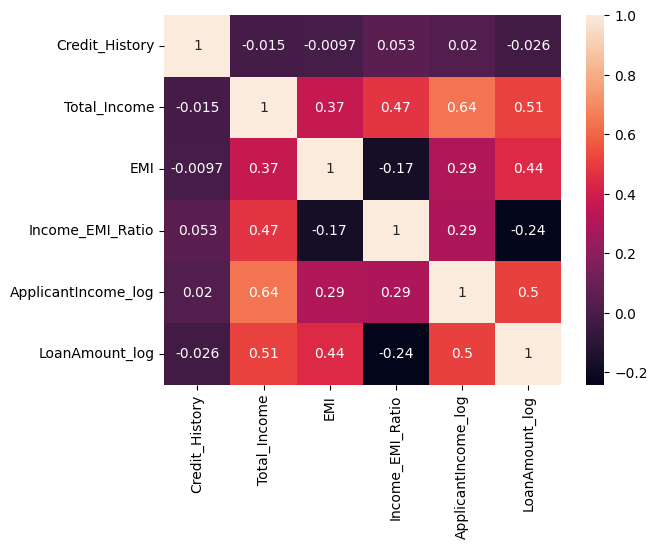

In [16]:
import seaborn as sns
sns.heatmap(df[num_cols].corr(), annot=True)